# Wigner Representation

$$W_{\ket{n}} = \frac{(-1)^n}{2\pi} L_n(x^2+p^2)e^{-\frac{x^2+p^2}{2}}$$

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import laguerre
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as ticker


In [74]:
#Define Wigner Function
def W(n, x, p):
    r2 = x**2+p**2
    return (-1)**n/(2*np.pi) * laguerre(n)(r2)*np.e**(-r2/2)

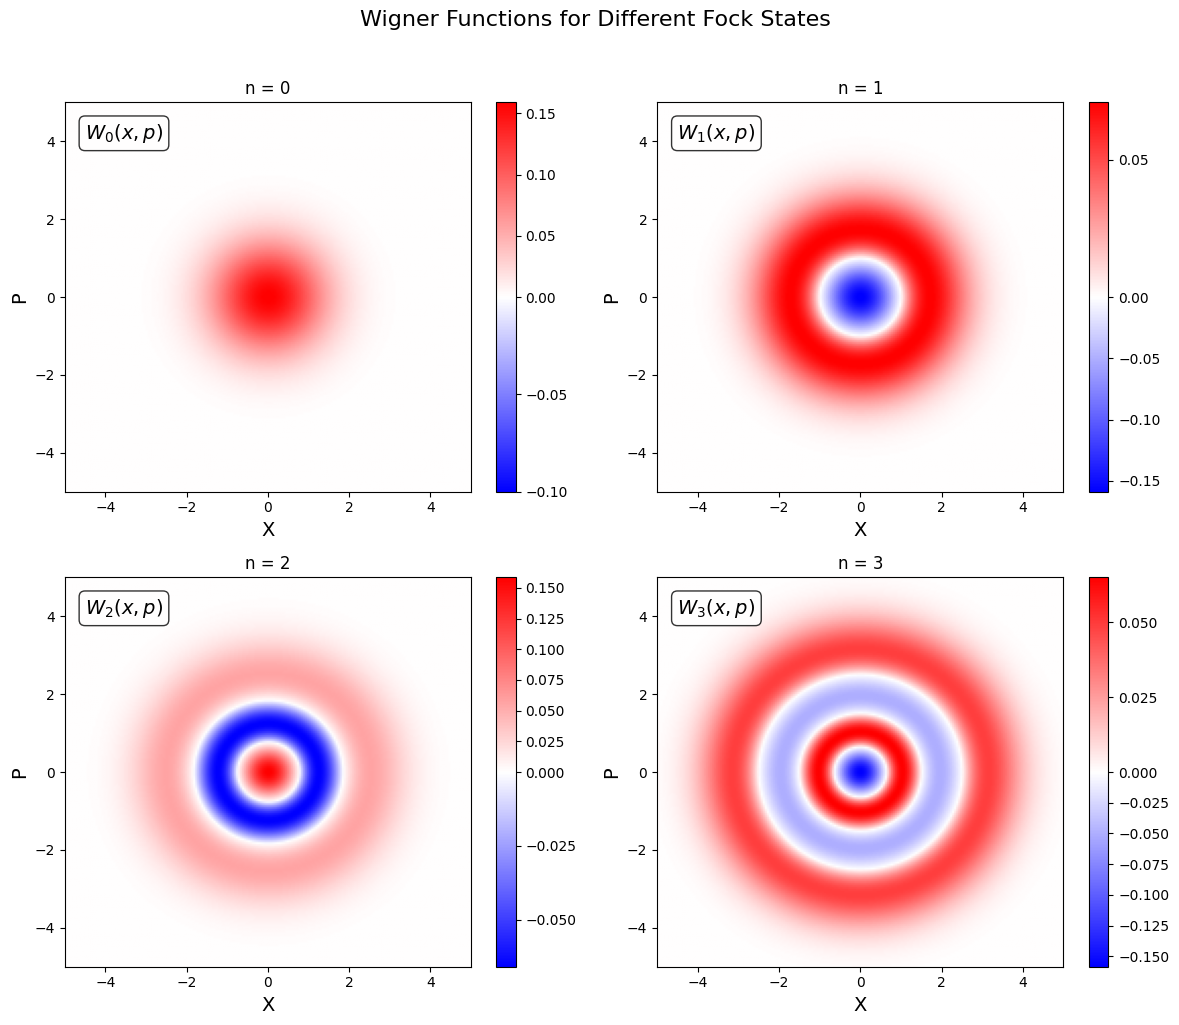

In [ ]:
# Create subplots for different n values
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  
n_values = [0, 1, 2, 3]

# Create grid 
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)

for idx, (ax, n) in enumerate(zip(axes.flat, n_values)):
    Z = W(n, X, Y)
    
    # Set up normalization centered at zero
    if n == 0:
        norm = TwoSlopeNorm(vmin=-0.1, vcenter=0, vmax=Z.max())
    else:
        norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
    
    # Create heatmap
    im = ax.imshow(Z, cmap='bwr', norm=norm,
                   extent=[x.min(), x.max(), y.min(), y.max()],
                   origin='lower', aspect='auto')
    
    ax.set_xlabel('X',fontsize=14)
    ax.set_ylabel('P',fontsize=14)
    ax.set_title(f'n = {n}')

    # Add colorbar to each subplot
    cbar = plt.colorbar(im)

    # Add LaTeX text W_n(x,p) 
    ax.text(0.05, 0.95, f'$W_{{{n}}}(x,p)$', 
            transform=ax.transAxes, 
            fontsize=14, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Wigner Functions for Different Fock States', fontsize=16,y=1.02)
plt.tight_layout()
plt.savefig('wigner_functions.png', dpi=300, bbox_inches='tight')
plt.show()